<a href="https://colab.research.google.com/github/chihway/mapping_the_universe/blob/main/Basic/Tutorial%202%20-%20Galaxy%20Catalogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 2 - Galaxy Catalogs

In this tutorial we will learn how to manipulate a galaxy catalog and make some simple plots. In this tutorial you will be able to

* read and understand what a fits file is
* read and understand what a hdf5 file is
* plot columns of the galaxy catalog
* manipulate the catalog and add new columns 
* use pandas to do some of these operations

If you already know all of this, feel free to skip to [Tutorial 3 - Galaxy Images](https://github.com/chihway/mapping_the_universe/blob/main/Basic/Tutorial%203%20-%20Galaxy%20Images.ipynb).


Here are some new python packages that are introduced in this tutorial:

* `astropy:`
* `h5py`: 
* `pandas`: 

In [2]:
import astropy
import astropy.io.fits as pf
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [3]:
# we need to first download some files -- these are the DES Y3 deep field catalogs
# you can read about the catalog here: https://arxiv.org/abs/2012.12824
# the schema of the catalog can be found here: https://des.ncsa.illinois.edu/releases/y3a2/Y3deepfields

# !curl -O https://portal.nersc.gov/cfs/lsst/chihway/mapping_the_universe/des_y3_deepfield.fits.gz
# !curl -O https://portal.nersc.gov/cfs/lsst/chihway/mapping_the_universe/des_y3_deepfield.h5.gz

## Reading and manipulating a FITS file

For the full information, please see https://docs.astropy.org/en/stable/io/fits/index.html

In [4]:
# read the file

fitsfile = pf.open('des_y3_deepfield.fits.gz')

In [5]:
# shows how many extensions the file has, for typical catalogs, the first extension (index 0)
# is usually empty, and the catalog content starts from the second (index 1) extension
# we also see that the catalog has 2826988 rows/objects, each with 22 columns/properties

fitsfile.info()

Filename: des_y3_deepfield.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1                1 BinTableHDU     65   2826988R x 24C   [K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, K, K, K]   


In [6]:
# you can see what the catalog contains from the header

fitsfile[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / 8-bit bytes                                    
NAXIS   =                    2 / 2-dimensional binary table                     
NAXIS1  =                  192 / width of table in bytes                        
NAXIS2  =              2826988 / number of rows in table                        
PCOUNT  =                    0 / size of special data area                      
GCOUNT  =                    1 / one data group (required keyword)              
TFIELDS =                   24 / number of fields in each row                   
TTYPE1  = 'ID      '           / label for field   1                            
TFORM1  = 'K       '           / data format of field: 8-byte INTEGER           
TTYPE2  = 'RA      '           / label for field   2                            
TFORM2  = 'D       '           / data format of field: 8-byte DOUBLE            
TTYPE3  = 'DEC     '        

In [7]:
# to access the data

fitsdata = fitsfile[1].data

In [8]:
# apply some basic masks to remove non-galaxy and other bad objects

mask = (fitsdata['KNN_CLASS']==1)*(fitsdata['FLAGS']==0)*(fitsdata['FLAGS_NIR']==0) \
                    *(fitsdata['MASK_FLAGS']==0)*(fitsdata['MASK_FLAGS_NIR']==0)

print('Number of objects after cuts:', len(fitsdata['RA'][mask]))

Number of objects after cuts: 1431620


Text(0.5, 0, 'Dec')

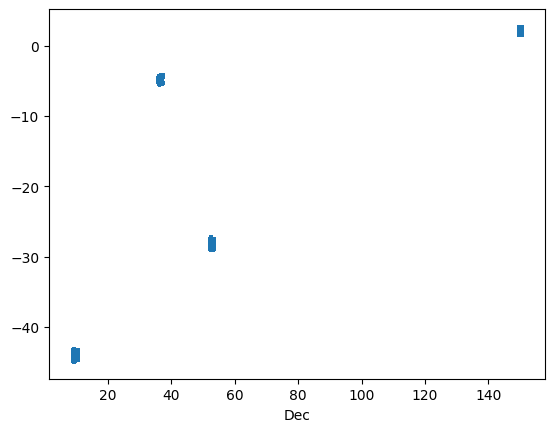

In [9]:
# plot the RA/DEC of the remaining objects to see where they are
# these are the 4 areas that cover the 10 deep fields: CDFS (SN-C1, SN-C2, SN-C3), 
# Elais-South (SN-E1, SN-E2), Stripe 82 (SN-S1, SN-S2) and XMM-LSS (SN-X1, SN-X2, SN-X3)

plt.scatter(fitsdata['RA'][mask], fitsdata['DEC'][mask], s=1)
plt.xlabel('RA')
plt.xlabel('Dec')

Text(0.5, 0, 'Dec')

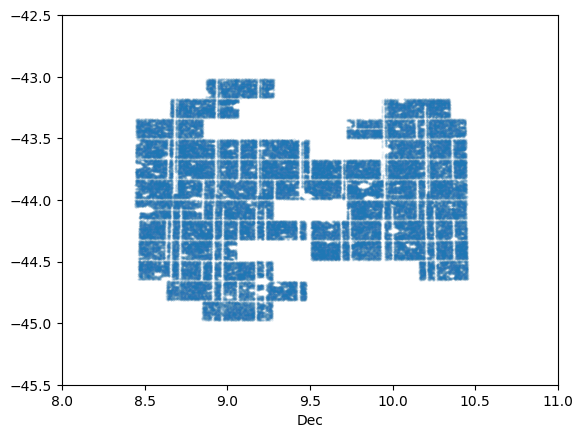

In [10]:
# zooming into one of the fields: Elais-South
plt.scatter(fitsdata['RA'][mask], fitsdata['DEC'][mask], s=0.1, alpha=0.1)
plt.xlim(8,11)
plt.ylim(-45.5,-42.5)
plt.xlabel('RA')
plt.xlabel('Dec')

/var/folders/mc/gj6kz6750g7dks2k81t8xyl80000gn/T/ipykernel_17727/950049240.py:7: RuntimeWarning: invalid value encountered in log10
  mag_g = -2.5*np.log10(fitsdata_mask['BDF_FLUX_DERED_CALIB_G'])+30.0
/var/folders/mc/gj6kz6750g7dks2k81t8xyl80000gn/T/ipykernel_17727/950049240.py:9: RuntimeWarning: invalid value encountered in log10
  mag_i = -2.5*np.log10(fitsdata_mask['BDF_FLUX_DERED_CALIB_I'])+30.0
/var/folders/mc/gj6kz6750g7dks2k81t8xyl80000gn/T/ipykernel_17727/950049240.py:11: RuntimeWarning: invalid value encountered in log10
  mag_j = -2.5*np.log10(fitsdata_mask['BDF_FLUX_DERED_CALIB_J'])+30.0


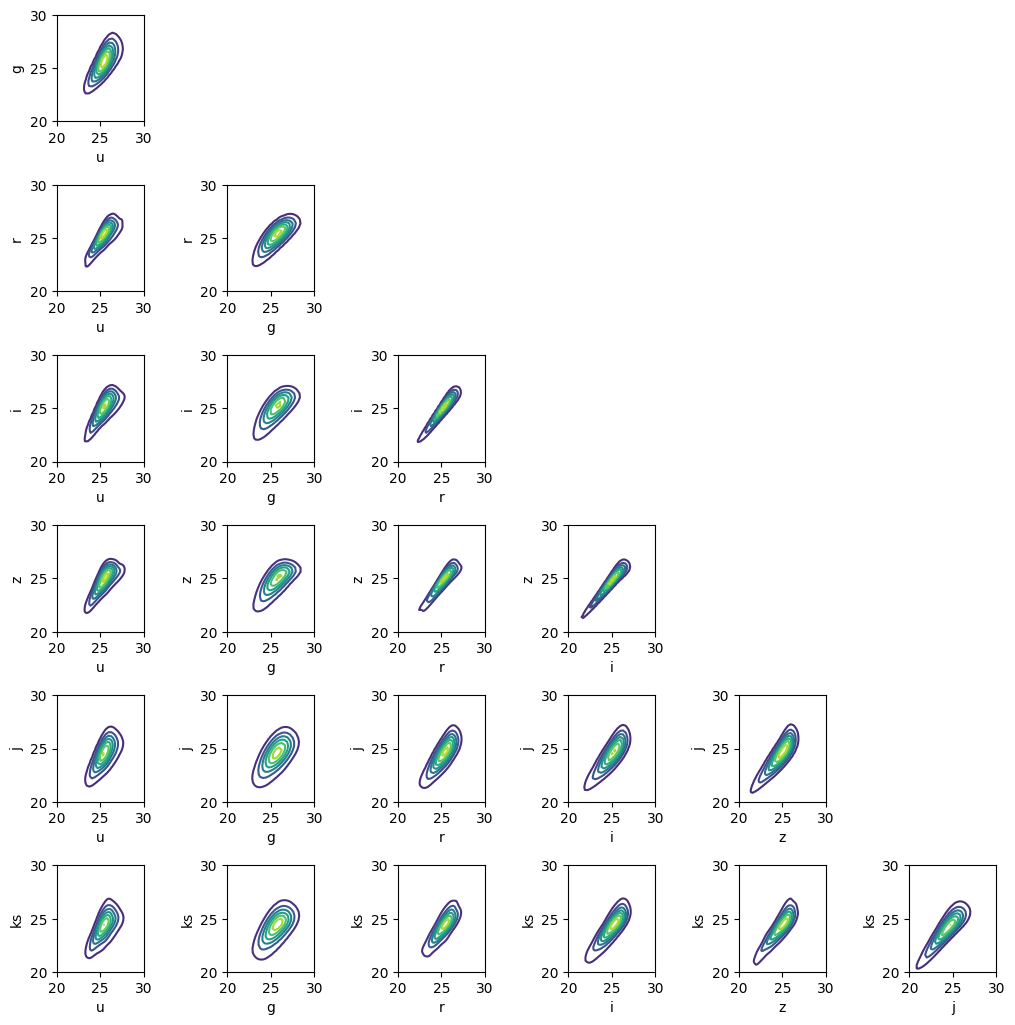

In [16]:
# make a color-color plot
fitsdata_mask = fitsdata[mask][:10000]

from scipy.stats import gaussian_kde

mag_u = -2.5*np.log10(fitsdata_mask['BDF_FLUX_DERED_CALIB_U'])+30.0
mag_g = -2.5*np.log10(fitsdata_mask['BDF_FLUX_DERED_CALIB_G'])+30.0
mag_r = -2.5*np.log10(fitsdata_mask['BDF_FLUX_DERED_CALIB_R'])+30.0
mag_i = -2.5*np.log10(fitsdata_mask['BDF_FLUX_DERED_CALIB_I'])+30.0
mag_z = -2.5*np.log10(fitsdata_mask['BDF_FLUX_DERED_CALIB_Z'])+30.0
mag_j = -2.5*np.log10(fitsdata_mask['BDF_FLUX_DERED_CALIB_J'])+30.0
mag_ks = -2.5*np.log10(fitsdata_mask['BDF_FLUX_DERED_CALIB_KS'])+30.0

mags = [mag_u,mag_g,mag_r,mag_i,mag_z,mag_j,mag_ks]
mags = np.nan_to_num(np.array(mags))
color = ['u','g','r','i','z','j','ks']

plt.figure(figsize=(12,12))
for i in range(7):
    for j in range(7):
        if i>j:
            
            # Calculate the point density using a kernel density estimation
            xy = np.vstack([mags[j], mags[i]])
            kde = gaussian_kde(xy)

            # Create a grid of points for the contour plot
            X, Y = np.mgrid[mags[i].min():mags[i].max():100j, mags[j].min():mags[j].max():100j]
            positions = np.vstack([X.ravel(), Y.ravel()])

            # Evaluate the KDE on the grid
            Z = np.reshape(kde(positions).T, X.shape)

            # Create the contour plot
            plt.subplot(7, 7, i*7+j+1)
            plt.contour(X, Y, Z)
            plt.xlabel(color[j])
            plt.ylabel(color[i])
            plt.xlim(20,30)
            plt.ylim(20,30)
#             plt.colorbar()


#             plt.subplot(7, 7, i*7+j+1)
#             plt.scatter(mags[i], mags[j], s=0.1, alpha=0.1)
plt.tight_layout()

In [41]:
# add a new magnitude column

In [42]:
# do the same for h5 file

In [ ]:
# use pandas

# https://pandas.pydata.org/docs/user_guide/10min.html

import pandas as pd
from astropy.io import fits

# Open the FITS file
with fits.open('your_fits_file.fits') as hdul:
    # Access the data from the desired HDU (e.g., the first one)
    data = hdul[1].data

    # Convert the FITS data to a pandas DataFrame
    df = pd.DataFrame(data)

# Now you can work with the FITS data in the DataFrame
print(df.head())